In [3]:
import pandas as pd

data = pd.read_csv("mushrooms.csv")

data.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


Import thư viện và nạp dữ liệu

In [4]:
# Import các thư viện cần thiết
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import CategoricalNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Đọc dữ liệu
df = pd.read_csv("mushrooms.csv")

# Hiển thị 5 dòng đầu tiên
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


Khám phá và xử lý dữ liệu trước khi xây dựng mô hình

(8124, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-a

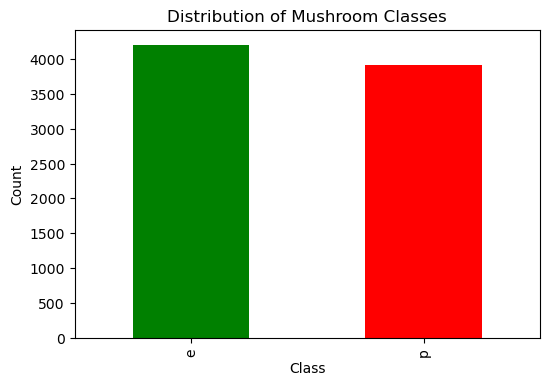

In [5]:
# Kiểm tra kích thước dữ liệu
print(df.shape)

# Kiểm tra kiểu dữ liệu
df.info()

# Kiểm tra dữ liệu thiếu
df.isnull().sum()

# Thống kê số lượng từng lớp
df["class"].value_counts()

# Trực quan phân bố lớp
df["class"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    color=["green","red"]
)

plt.title("Distribution of Mushroom Classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Tiền xử lý dữ liệu

In [6]:
# Mã hóa dữ liệu
encoder = LabelEncoder()

for col in df.columns:
    df[col] = encoder.fit_transform(df[col])

# Tách đặc trưng và nhãn
X = df.drop("class", axis=1)
y = df["class"]

# Chia dữ liệu Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Xây dựng mô hình Naive

In [7]:
classifier = CategoricalNB()

classifier.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,min_categories,None


Đánh giá hiệu quả của mô hình

Accuracy: 0.9507692307692308
Confusion Matrix
[[837   6]
 [ 74 708]]
Classification Report
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       843
           1       0.99      0.91      0.95       782

    accuracy                           0.95      1625
   macro avg       0.96      0.95      0.95      1625
weighted avg       0.95      0.95      0.95      1625



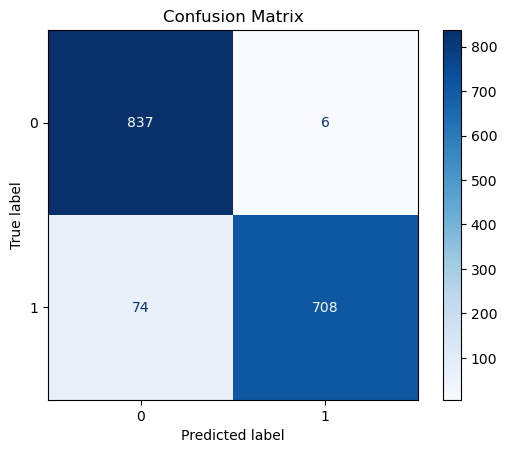

In [8]:
# Dự đoán
y_pred = classifier.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(conf_matrix)

# Classification Report
classification_rep = classification_report(y_test, y_pred)

print("Classification Report")
print(classification_rep)

# Trực quan Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

Dự đoán thử một mẫu

In [9]:
sample = X.iloc[[0]]

prediction = classifier.predict(sample)

print("Prediction:", prediction[0])
print("Actual:", y.iloc[0])

Prediction: 0
Actual: 1
